# Clean power data, convert to energy data, and save to file for future use

In [1]:
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date, datetime, timedelta
from itertools import product
from copy import deepcopy
from clean_and_collect_power_data import Clean
from PreRun import PreRun
#from gen_variable_standard_static import metrics_search_for_two_fragments_df

In [2]:
#systems_cleaned
systems_cleaned = pd.read_csv("../../../data/core/systems_cleaned.csv")
#path to read from
read_from_path = "../../../../data_ds_project/testing_yearly_parquet/testing_yearly_parquet/"
#path to write to
write_to_path = "../../../../data_ds_project/parquet_cleaned_energy"

#make a list of all system_id's to choose from. They will be strings and organized in alphabetical order.
base_path = Path(read_from_path)
# all_parquet_systems = [p.name for p in base_path.iterdir() if p.is_dir()]
# all_parquet_systems
good_systems_list = [4, 10, 33, 36, 50, 51, 1199, 1204, 1283, 1284, 1289, 1332, 4902, 4903]
reader_types = ["meter", "inverter", None]

Now clean and download for all parquet systems with good time zone data! (commented out since it already ran)

In [3]:
# for system_id, meter_or_inverter in product(good_systems_list, reader_types):
#     make_energy = Clean(system_id, read_from_path, systems_cleaned, meter_or_inverter, write_to_path)
#     make_energy.clean_all_and_write_to_file()


# Goal: test the PreRun class.

In [4]:
system_id = '4'
check_prerun = PreRun(system_id, write_to_path, None, systems_cleaned)

                     time    energy
0     2007-09-01 06:00:00  0.032494
1     2007-09-01 07:00:00  0.159633
2     2007-09-01 08:00:00  0.304443
3     2007-09-01 09:00:00  0.265836
4     2007-09-01 10:00:00  0.804245
...                   ...       ...
34818 2023-02-28 13:00:00  0.610406
34819 2023-02-28 14:00:00  0.408742
34820 2023-02-28 15:00:00  0.395145
34821 2023-02-28 16:00:00  0.230329
34822 2023-02-28 17:00:00  0.003725

[34823 rows x 2 columns]


In [5]:
#check_prerun.load_data()
check_prerun.good_days

,date
0,2007-09-01
1,2007-09-03
2,2007-09-04
3,2007-09-07
4,2007-09-08
...,...
2887,2023-02-20
2888,2023-02-21
2889,2023-02-26
2890,2023-02-27


In [6]:
# Now in the constructor
# check_prerun.fix_timezones()
# check_prerun.amended_data.head(10)

In [7]:
# check_prerun.add_energy_features_only(daily_lags=3, remove_daily_lags_nans=False, include_last_year=True, remove_last_year_nans=False, todays_lags=3, remove_todays_lags_nans=False, include_month=True, include_day_of_month=True, include_hour=True)
# check_prerun.amended_data.head(10)

In [8]:
len(check_prerun.amended_data)

34823

In [9]:
len(check_prerun.good_days)

2892

In [10]:
len(check_prerun.good_end_days_naive(7))

           date  streak_id
0    2007-09-01          1
1    2007-09-03          2
2    2007-09-04          2
3    2007-09-07          3
4    2007-09-08          3
...         ...        ...
2887 2023-02-20        891
2888 2023-02-21        891
2889 2023-02-26        892
2890 2023-02-27        892
2891 2023-02-28        892

[2892 rows x 2 columns]


101

In [11]:
check_prerun.add_weather_features_only()
check_prerun.amended_data.head(10)

,time,energy,cloud_cover,global_tilted_irradiance
0,2007-09-01 06:00:00,0.032494,0.42,15.121737
1,2007-09-01 07:00:00,0.159633,0.37,127.388847
2,2007-09-01 08:00:00,0.304443,0.33,214.694809
3,2007-09-01 09:00:00,0.265836,0.24,284.521942
4,2007-09-01 10:00:00,0.804245,0.34,334.852509
5,2007-09-01 11:00:00,0.259111,0.49,365.248993
6,2007-09-01 12:00:00,0.161788,0.48,373.767242
7,2007-09-01 13:00:00,0.704303,0.62,379.148590
8,2007-09-01 14:00:00,0.536415,0.66,357.039490
9,2007-09-01 15:00:00,0.381660,0.90,304.574554


In [13]:
check_prerun.amended_data.head(50)

,time,energy,cloud_cover,global_tilted_irradiance
0,2007-09-01 06:00:00,0.032494,0.42,15.121737
1,2007-09-01 07:00:00,0.159633,0.37,127.388847
2,2007-09-01 08:00:00,0.304443,0.33,214.694809
3,2007-09-01 09:00:00,0.265836,0.24,284.521942
4,2007-09-01 10:00:00,0.804245,0.34,334.852509
5,2007-09-01 11:00:00,0.259111,0.49,365.248993
6,2007-09-01 12:00:00,0.161788,0.48,373.767242
7,2007-09-01 13:00:00,0.704303,0.62,379.148590
8,2007-09-01 14:00:00,0.536415,0.66,357.039490
9,2007-09-01 15:00:00,0.381660,0.90,304.574554


<Axes: xlabel='global_tilted_irradiance', ylabel='energy'>

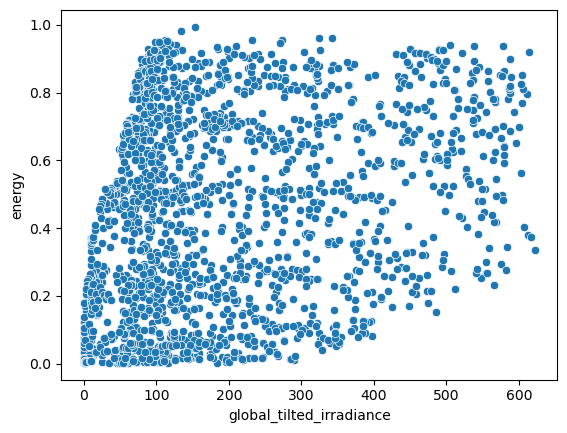

In [22]:
# plot energy vs irradiance
import seaborn as sns
sns.scatterplot(data=check_prerun.amended_data.iloc[1:2000], x='global_tilted_irradiance', y='energy')


<Axes: xlabel='cloud_cover', ylabel='energy'>

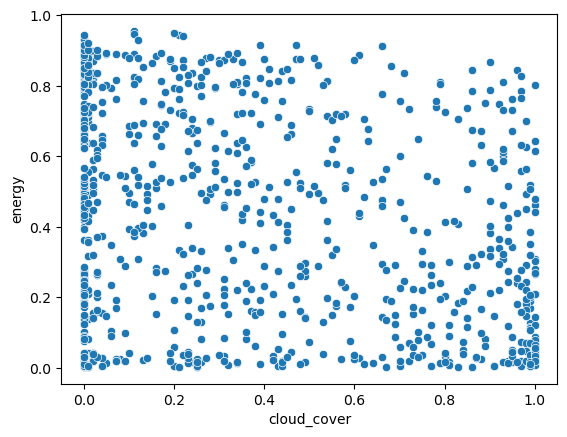

In [21]:
sns.scatterplot(data=check_prerun.amended_data.iloc[:1000], x='cloud_cover', y='energy')
